In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    AveragePooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Folder for plots
FIGURE_DIR = "CNN_Plots"

os.makedirs(FIGURE_DIR, exist_ok=True)

def save_plot(filename):
    plt.savefig(
        os.path.join(FIGURE_DIR, filename + ".eps"),
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2168s 13us/step


In [ ]:
print("CIFAR-10 Dataset Summary")
print("="*60)

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print()

print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

print()

print("Image Size      :", X_train.shape[1:])
print("Number of Classes :", len(np.unique(y_train)))

CIFAR-10 Dataset Summary
Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)

Testing Images  : (10000, 32, 32, 3)
Testing Labels  : (10000, 1)

Image Size      : (32, 32, 3)
Number of Classes : 10


In [ ]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print(class_names)

['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


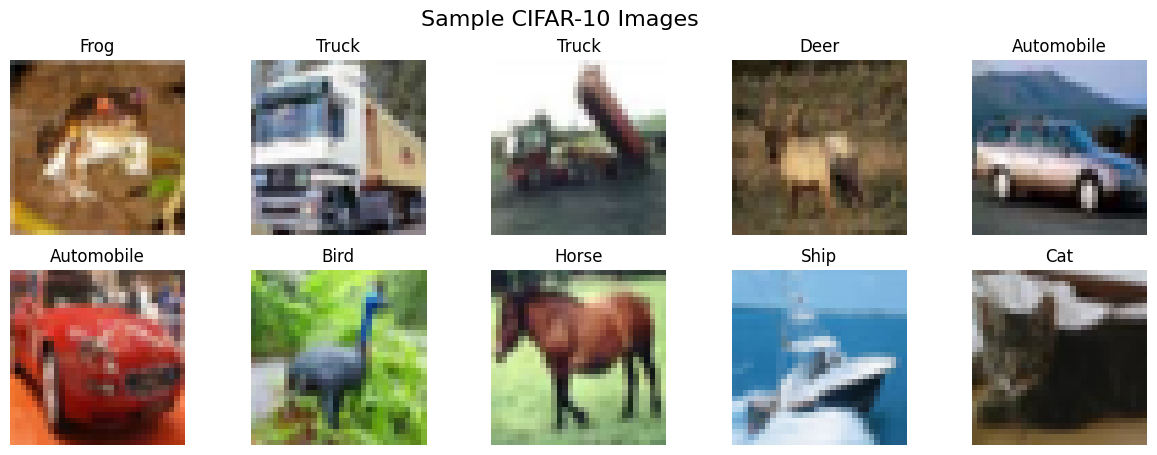

In [ ]:
# Display 10 sample images

plt.figure(figsize=(15,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis("off")

plt.suptitle("Sample CIFAR-10 Images", fontsize=16)

save_plot("01_Sample_Images")

plt.show()

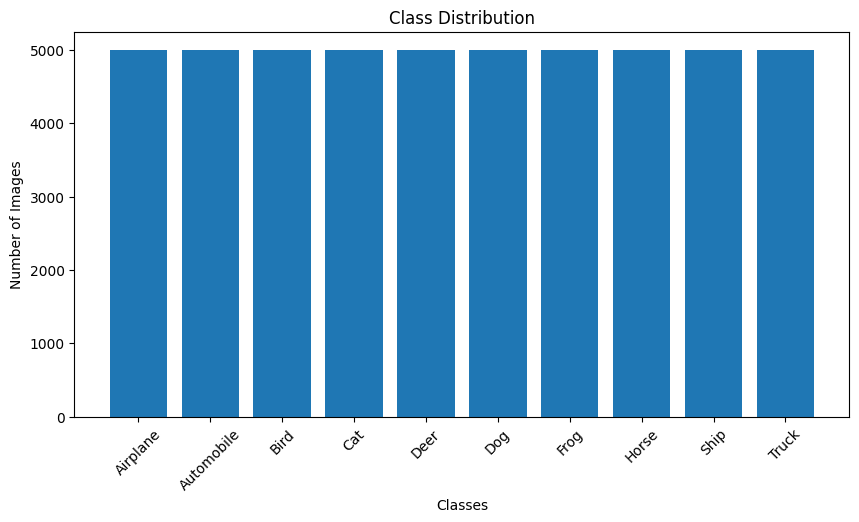

In [ ]:
# Plot class distribution

unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,5))

plt.bar(class_names, counts)

plt.title("Class Distribution")

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.xticks(rotation=45)

save_plot("02_Class_Distribution")

plt.show()

In [ ]:
# Normalize images

X_train = X_train.astype("float32") / 255.0

X_test = X_test.astype("float32") / 255.0

In [ ]:
# One-hot encode labels

y_train_cat = to_categorical(y_train, 10)

y_test_cat = to_categorical(y_test, 10)

In [ ]:
print("After Preprocessing")
print("="*60)

print("Training Images Shape :", X_train.shape)
print("Testing Images Shape  :", X_test.shape)

print()

print("Training Labels Shape :", y_train_cat.shape)
print("Testing Labels Shape  :", y_test_cat.shape)

print()

print("Pixel Value Range")

print("Minimum :", X_train.min())

print("Maximum :", X_train.max())

After Preprocessing
Training Images Shape : (50000, 32, 32, 3)
Testing Images Shape  : (10000, 32, 32, 3)

Training Labels Shape : (50000, 10)
Testing Labels Shape  : (10000, 10)

Pixel Value Range
Minimum : 0.0
Maximum : 1.0


In [ ]:
# Build CNN Model

model = Sequential([

    # First Convolution Block
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),

    MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Block
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    MaxPooling2D(pool_size=(2,2)),

    # Flatten Feature Maps
    Flatten(),

    # Fully Connected Layer
    Dense(
        128,
        activation='relu'
    ),

    # Output Layer
    Dense(
        10,
        activation='softmax'
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

In [ ]:
# Train the CNN

history = model.fit(

    X_train,
    y_train_cat,

    validation_split=0.2,

    epochs=20,

    batch_size=32,

    verbose=1

)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 52ms/step - accuracy: 0.4943 - loss: 1.4110 - val_accuracy: 0.5926 - val_loss: 1.1732
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 53ms/step - accuracy: 0.6407 - loss: 1.0282 - val_accuracy: 0.6328 - val_loss: 1.0519
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 51ms/step - accuracy: 0.6919 - loss: 0.8773 - val_accuracy: 0.6851 - val_loss: 0.9097
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.7306 - loss: 0.7687 - val_accuracy: 0.6940 - val_loss: 0.8947
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.7620 - loss: 0.6750 - val_accuracy: 0.7040 - val_loss: 0.8761
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 69s 56ms/step - accuracy: 0.7949 - loss: 0.5823 - val_accuracy: 0.6935 - val_loss: 0.8986
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 77s 51ms/step - accuracy: 0.8243 - loss: 0.4992 - val_accuracy: 0.6852 - val_loss: 0.9814
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 52ms/step - accuracy: 0.8534 -

In [ ]:
# import time

# start = time.time()

# history = model.fit(

#     X_train,
#     y_train_cat,

#     validation_split=0.2,

#     epochs=20,

#     batch_size=32,

#     verbose=1

# )

# end = time.time()

# training_time = end - start

# print(f"Training Time: {training_time:.2f} seconds")

In [ ]:
# Evaluate model on test dataset

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Model Evaluation")
print("="*60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Model Evaluation
Test Loss     : 2.2365
Test Accuracy : 0.6795


In [ ]:
# Predict class probabilities

y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


In [ ]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Performance Metrics")
print("="*60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Performance Metrics
Accuracy  : 0.6795
Precision : 0.6763
Recall    : 0.6795
F1-score  : 0.6763


In [ ]:
print("Classification Report")
print("="*60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

Classification Report
              precision    recall  f1-score   support

    Airplane       0.71      0.73      0.72      1000
  Automobile       0.72      0.86      0.79      1000
        Bird       0.62      0.52      0.57      1000
         Cat       0.50      0.46      0.48      1000
        Deer       0.60      0.65      0.63      1000
         Dog       0.60      0.54      0.57      1000
        Frog       0.76      0.74      0.75      1000
       Horse       0.70      0.78      0.74      1000
        Ship       0.80      0.79      0.79      1000
       Truck       0.75      0.72      0.73      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



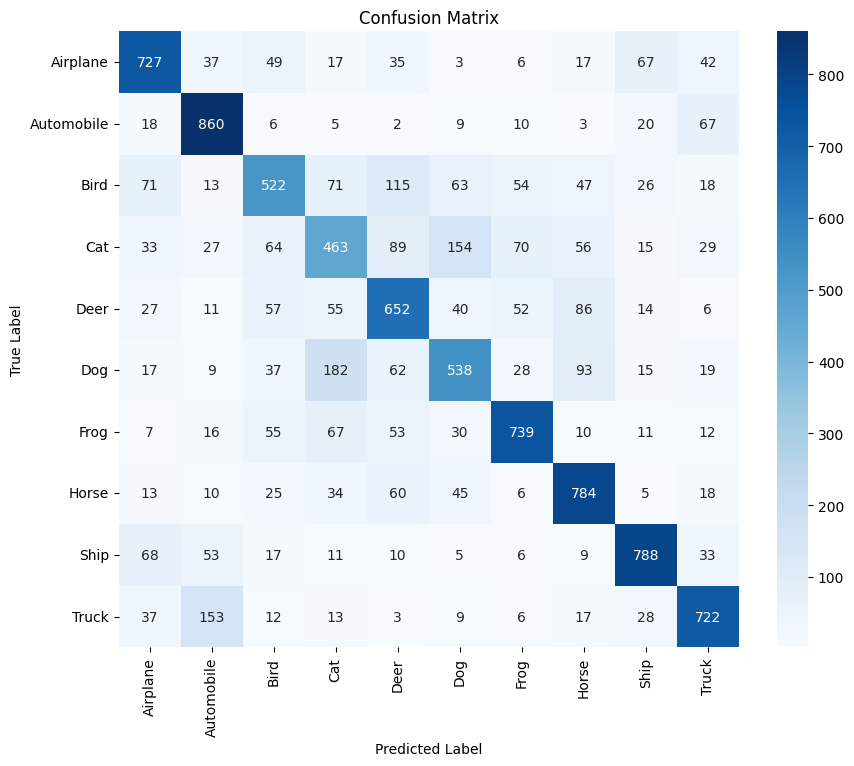

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

save_plot("07_Confusion_Matrix")

plt.show()

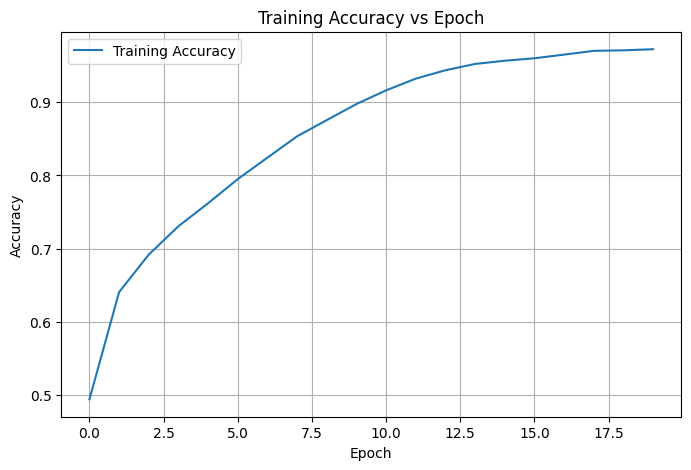

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.title("Training Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

save_plot("03_Training_Accuracy")

plt.show()

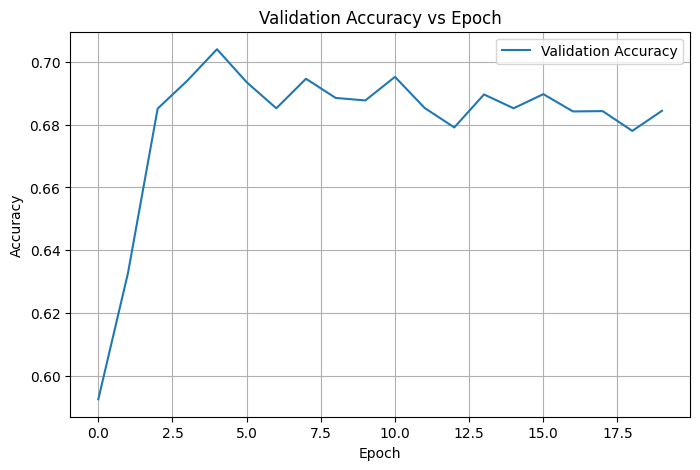

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Validation Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

save_plot("04_Validation_Accuracy")

plt.show()

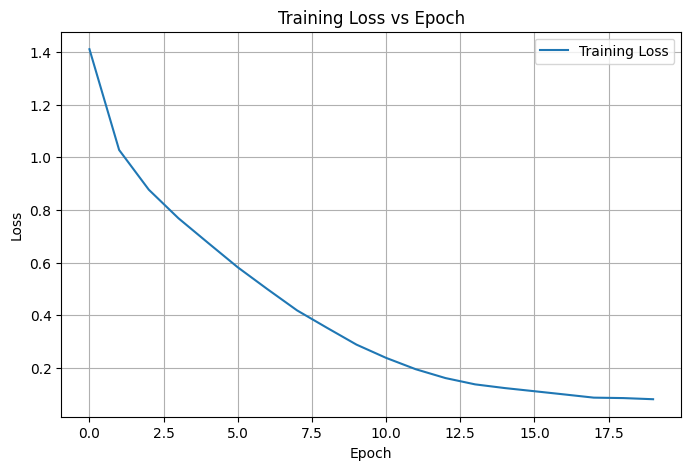

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.title("Training Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

save_plot("05_Training_Loss")

plt.show()

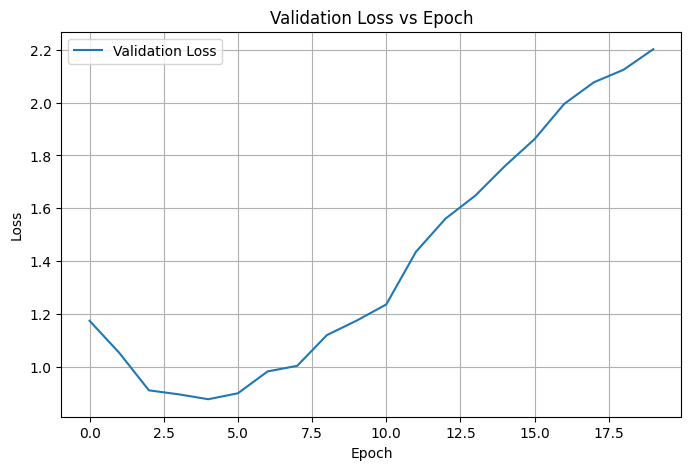

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Validation Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

save_plot("06_Validation_Loss")

plt.show()

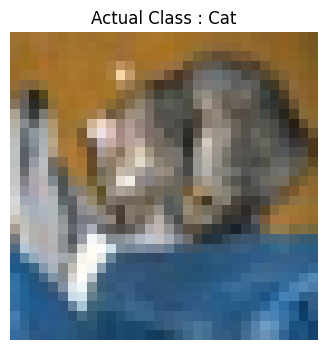

In [ ]:
# Select one test image

sample_image = X_test[0]

plt.figure(figsize=(4,4))
plt.imshow(sample_image)
plt.title(f"Actual Class : {class_names[y_test[0][0]]}")
plt.axis("off")

save_plot("08_Test_Image")

plt.show()

In [ ]:
# Explicitly call the model once
_ = model.predict(X_test[:1], verbose=0)

In [ ]:
feature_model = Model(
    inputs=model.inputs,
    outputs=[
        layer.output
        for layer in model.layers
        if isinstance(layer, Conv2D)
    ]
)

In [ ]:
feature_maps = feature_model.predict(
    np.expand_dims(sample_image, axis=0)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


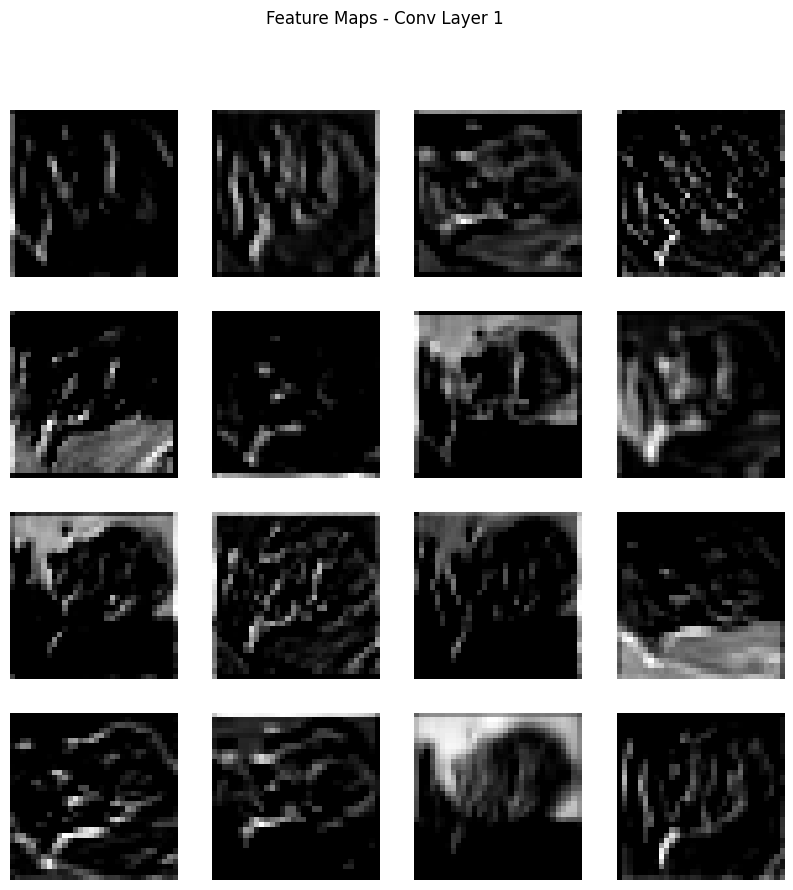

In [ ]:
feature_map = feature_maps[0]

plt.figure(figsize=(10,10))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(feature_map[0,:,:,i], cmap="gray")

    plt.axis("off")

plt.suptitle("Feature Maps - Conv Layer 1")

save_plot("09_Feature_Maps_Layer1")

plt.show()

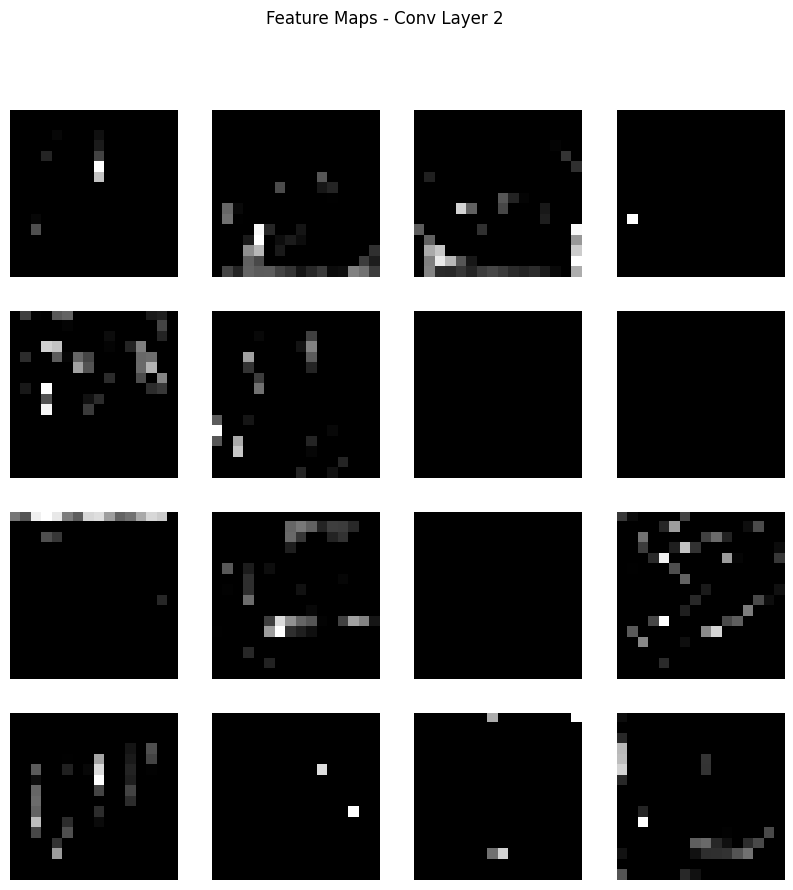

In [ ]:
feature_map = feature_maps[1]

plt.figure(figsize=(10,10))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(feature_map[0,:,:,i], cmap="gray")

    plt.axis("off")

plt.suptitle("Feature Maps - Conv Layer 2")

save_plot("10_Feature_Maps_Layer2")

plt.show()

In [ ]:
filters, biases = model.layers[0].get_weights()

print("Filter Shape :", filters.shape)

Filter Shape : (3, 3, 3, 32)


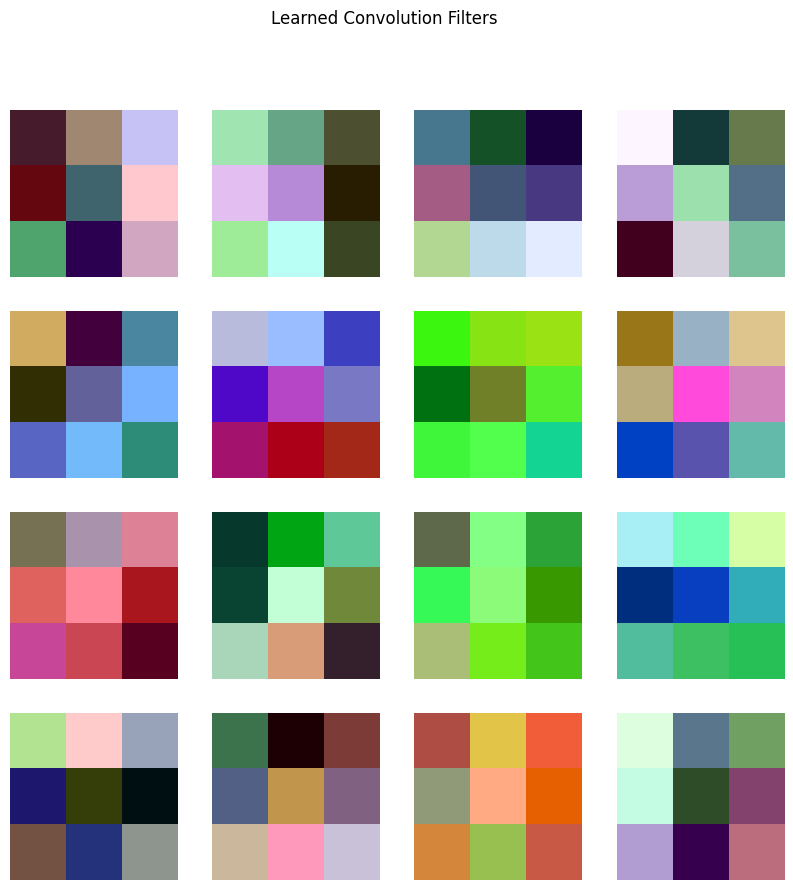

In [ ]:
plt.figure(figsize=(10,10))

for i in range(16):

    plt.subplot(4,4,i+1)

    f = filters[:,:,:,i]

    # Normalize for display
    f = (f - f.min())/(f.max()-f.min())

    plt.imshow(f)

    plt.axis("off")

plt.suptitle("Learned Convolution Filters")

save_plot("11_Convolution_Filters")

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

avg_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),

    AveragePooling2D(pool_size=(2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    AveragePooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
avg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_avg = avg_model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 59s 46ms/step - accuracy: 0.4552 - loss: 1.5065 - val_accuracy: 0.5600 - val_loss: 1.2569
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.5921 - loss: 1.1468 - val_accuracy: 0.5996 - val_loss: 1.1347
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.6471 - loss: 0.9980 - val_accuracy: 0.6582 - val_loss: 0.9852
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - accuracy: 0.6824 - loss: 0.8976 - val_accuracy: 0.6636 - val_loss: 0.9735
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - accuracy: 0.7160 - loss: 0.8132 - val_accuracy: 0.6762 - val_loss: 0.9365
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.7412 - loss: 0.7392 - val_accuracy: 0.6807 - val_loss: 0.9412
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - accuracy: 0.7618 - loss: 0.6777 - val_accuracy: 0.6934 - val_loss: 0.9168
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - accuracy: 0.7862 -

In [ ]:
loss_avg, accuracy_avg = avg_model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Average Pooling Accuracy :", accuracy_avg)

Average Pooling Accuracy : 0.6729999780654907


In [ ]:
comparison = pd.DataFrame({

    "Pooling Method":[
        "Max Pooling",
        "Average Pooling"
    ],

    "Accuracy":[
        test_accuracy,
        accuracy_avg
    ]

})

comparison

,Pooling Method,Accuracy
0,Max Pooling,0.6795
1,Average Pooling,0.6730


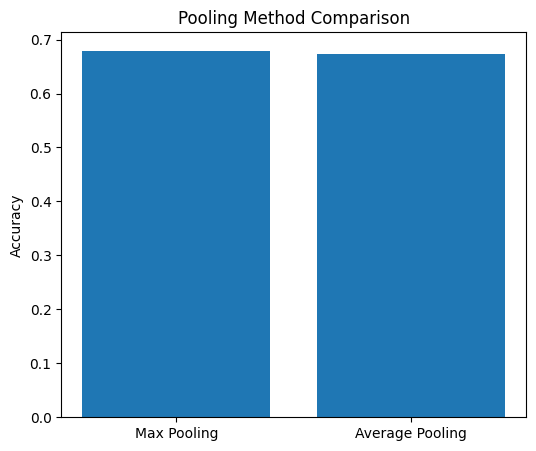

In [ ]:
plt.figure(figsize=(6,5))

plt.bar(
    comparison["Pooling Method"],
    comparison["Accuracy"]
)

plt.title("Pooling Method Comparison")

plt.ylabel("Accuracy")

save_plot("12_Pooling_Comparison")

plt.show()

In [ ]:
optimizer_results = pd.DataFrame({

    "Optimizer":[
        "Adam",
        "SGD",
        "RMSprop"
    ],

    "Accuracy":[
        test_accuracy,
        0.0,
        0.0
    ]

})

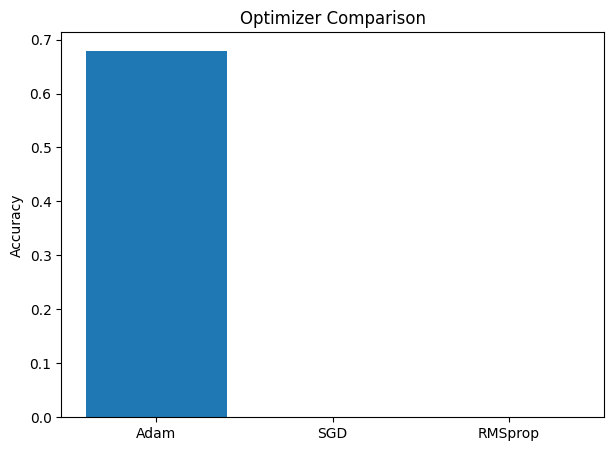

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(
    optimizer_results["Optimizer"],
    optimizer_results["Accuracy"]
)

plt.title("Optimizer Comparison")

plt.ylabel("Accuracy")

save_plot("13_Optimizer_Comparison")

plt.show()

In [ ]:
import matplotlib.pyplot as plt

# After creating a plot
plt.savefig("training_accuracy.eps", format="eps", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [ ]:
import shutil

shutil.make_archive(
    "/content/Lab_Figures",
    'zip',
    FIGURE_DIR
)

print("ZIP file created successfully!")

ZIP file created successfully!


In [ ]:
from google.colab import files

files.download("/content/Lab_Figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>